# Can a Residual Correction on NESO's Own Forecast Close the Trough Gap?

`notebooks/17` tested Elexon `FUELHH` (actual generation by fuel type) as a feature and found only a modest, leaky improvement — same-period actuals aren't available at prediction time, so that result was a ceiling, not a deployable gain.

This notebook tests a genuinely deployable idea instead: Elexon's **`NDF`** (`src/edf/data/ndf.py`) is National Grid ESO's own half-hourly demand forecast, republished on a rolling basis — unlike the leaky fuel-mix data, this is a real **forecast**, and we specifically keep only the revision that existed the day before delivery, so it's exactly what would have been available at prediction time.

Rather than competing with NESO from scratch (the `notebooks/16` framing), this trains a **residual-correction model**: predict `actual − NDF` using our existing weather/calendar/lag features, then report `NDF + predicted_residual` as the final forecast. Where NDF is already accurate (the trough), the residual is small and easy to predict, so we inherit NESO's own trough accuracy; where our features carry information NDF's forecast doesn't fully use, the correction can still improve on it.

**One real cost, addressed directly below**: NDF's archive only goes back to 2021-06-14 (verified live), so any model using it loses about 1.5 years of TRAIN (2020-01-01 to 2021-06-13). To keep the comparison fair, the baseline in this notebook is *also* retrained on the matched, NDF-available TRAIN window — so any improvement measured is attributable to NDF, not to an apples-to-oranges TRAIN-size difference.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.models.baselines import previous_week_same_time
from edf.features.buckets import build_day_type_buckets, is_christmas_period
from edf.evaluate import evaluate
from edf.features.demand import build_feature_table
from edf.models.forecast import train_lightgbm
from edf.features.generation import capacity_factor
from edf.features.weather import build_weather_feature_table

pd.options.display.float_format = "{:.2f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]
POINT_PARAMS = {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05}
POINT_N_ESTIMATORS = 689
UPWEIGHT = 3.0

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
ndf = pd.read_parquet("../data/raw/elexon_ndf_day_ahead.parquet")["ndf_day_ahead"]
print(f"NDF day-ahead coverage: {ndf.index.min()} to {ndf.index.max()} ({len(ndf)} rows)")

NDF day-ahead coverage: 2021-06-14 23:00:00+00:00 to 2024-12-31 23:30:00+00:00 (61020 rows)


## Rebuild the baseline on a matched (NDF-available) TRAIN window

Same bias-corrected recipe as every prior notebook this session, but TRAIN is restricted to rows where NDF is actually available — the same rows the residual-correction model below gets to train on. The *original* full-TRAIN baseline is also kept, purely to quantify the cost of the shorter TRAIN window.

In [3]:
wind_cf_full = capacity_factor(df["wind"], df["wind_capacity"])
day_buckets_full = build_day_type_buckets(era5["temperature_c"], wind_cf_full)
problem_mask = day_buckets_full["is_hot"] | day_buckets_full["is_high_wind"] | day_buckets_full["is_christmas"]
weight_full = pd.Series(1.0, index=df.index)
weight_full[problem_mask] = UPWEIGHT

era5_chr = era5.copy()
era5_chr["is_christmas"] = is_christmas_period(df.index)

X_base, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5_chr)
ndf_aligned = ndf.reindex(X_base.index)
has_ndf = ndf_aligned.notna()

X_val, y_val = X_base.loc[val_start:val_end], y.loc[val_start:val_end]
weight_val = weight_full.loc[X_val.index]

# full-TRAIN baseline (original recipe, unrestricted) - for reference only
X_train_full, y_train_full = X_base.loc[train_start:train_end], y.loc[train_start:train_end]
model_base_full = train_lightgbm(
    X_train_full, y_train_full, sample_weight=weight_full.loc[X_train_full.index],
    n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)
preds_base_full = pd.Series(model_base_full.predict(X_val), index=X_val.index)

# matched-TRAIN baseline (NDF-available rows only) - the fair comparison point
train_mask = has_ndf.loc[train_start:train_end]
X_train_matched = X_base.loc[train_start:train_end][train_mask]
y_train_matched = y.loc[train_start:train_end][train_mask]
model_base_matched = train_lightgbm(
    X_train_matched, y_train_matched, sample_weight=weight_full.loc[X_train_matched.index],
    n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)
preds_base_matched = pd.Series(model_base_matched.predict(X_val), index=X_val.index)

print(f"TRAIN rows: full={len(X_train_full)}, NDF-matched={len(X_train_matched)} "
      f"({len(X_train_full) - len(X_train_matched)} dropped to pre-archive dates)")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5693
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 27001.358990


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5692
[LightGBM] [Info] Number of data points in the train set: 43452, number of used features: 30
[LightGBM] [Info] Start training from score 26685.786032


TRAIN rows: full=68784, NDF-matched=43452 (25332 dropped to pre-archive dates)


## Residual-correction model: predict `actual − NDF`, then add NDF back

Same features, same TRAIN rows as the matched baseline above — the only difference is the *target*: `demand − NDF` instead of `demand`. Final prediction is `NDF + predicted_residual`, evaluated only where VALIDATION actually has NDF coverage (all of it, since NDF's archive covers the full VALIDATION year).

In [4]:
y_resid_train = y_train_matched - ndf_aligned.loc[X_train_matched.index]
model_resid = train_lightgbm(
    X_train_matched, y_resid_train, sample_weight=weight_full.loc[X_train_matched.index],
    n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)

resid_hat = pd.Series(model_resid.predict(X_val), index=X_val.index)
ndf_val = ndf_aligned.loc[X_val.index]
preds_corrected = ndf_val + resid_hat
preds_ndf_alone = ndf_val

print(f"VALIDATION rows with NDF coverage: {ndf_val.notna().sum()} / {len(X_val)}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5692
[LightGBM] [Info] Number of data points in the train set: 43452, number of used features: 30
[LightGBM] [Info] Start training from score -33.864333


VALIDATION rows with NDF coverage: 17568 / 17568


## Head-to-head, restricted to NESO's trough cardinal points

In [5]:
neso = pd.read_parquet("../data/raw/neso_day_ahead_demand_forecast.parquet").set_index("timestamp")
neso = neso[~neso.index.duplicated(keep="first")]
neso_val = neso.loc[val_start:val_end]

common = X_val.index.intersection(neso_val.index)
trough = common[neso_val.loc[common, "CP_TYPE"] == "T"]

naive_mae_trough = evaluate(
    demand.loc[trough], previous_week_same_time(demand).loc[trough]
)["mae"]

results = pd.DataFrame(
    {
        "baseline, full TRAIN (trough)": evaluate(y_val.loc[trough], preds_base_full.loc[trough], seasonal_naive_mae=naive_mae_trough),
        "baseline, matched TRAIN (trough)": evaluate(y_val.loc[trough], preds_base_matched.loc[trough], seasonal_naive_mae=naive_mae_trough),
        "NDF alone (trough)": evaluate(y_val.loc[trough], preds_ndf_alone.loc[trough], seasonal_naive_mae=naive_mae_trough),
        "NDF + residual correction (trough)": evaluate(y_val.loc[trough], preds_corrected.loc[trough], seasonal_naive_mae=naive_mae_trough),
        "NESO archive (trough)": evaluate(demand.loc[trough], neso_val.loc[trough, "forecast_demand_mw"], seasonal_naive_mae=naive_mae_trough),
        "baseline, full TRAIN (overall)": evaluate(y_val, preds_base_full),
        "baseline, matched TRAIN (overall)": evaluate(y_val, preds_base_matched),
        "NDF alone (overall)": evaluate(y_val, preds_ndf_alone),
        "NDF + residual correction (overall)": evaluate(y_val, preds_corrected),
    }
).T
results[["mae", "mase", "bias", "n"]]

,mae,mase,bias,n
"baseline, full TRAIN (trough)",901.71,0.45,-176.42,857.00
"baseline, matched TRAIN (trough)",890.30,0.44,-154.94,857.00
NDF alone (trough),502.07,0.25,63.37,857.00
NDF + residual correction (trough),500.58,0.25,31.31,857.00
NESO archive (trough),618.64,0.31,227.85,857.00
"baseline, full TRAIN (overall)",885.70,NaN,-137.78,17568.00
"baseline, matched TRAIN (overall)",886.36,NaN,-135.82,17568.00
NDF alone (overall),534.46,NaN,1.77,17568.00
NDF + residual correction (overall),542.58,NaN,20.03,17568.00


## Finding: NDF alone dwarfs our from-scratch model — the correction barely moves it

| | trough MAE | overall MAE (n=17,568) |
|---|---|---|
| baseline (matched TRAIN) | 890.30 | 886.36 |
| NDF alone | 502.07 | 534.46 |
| NDF + residual correction | **500.58** | 542.58 |

Two things, and they cut in different directions:

1. **NDF alone is dramatically more accurate than our from-scratch model — across the *entire* half-hourly VALIDATION year, not just the trough.** This is a genuinely richer comparison than `notebooks/16`'s: that one could only compare at ~12 coarse cardinal points/day because that's all the NESO portal archive retains. NDF is published half-hourly, so here the baseline gets compared against NDF on all 17,568 VALIDATION half-hours. The conclusion generalizes past "NESO wins at the trough" to "NESO's operational forecast is just a lot more accurate than a weather/calendar/lag model, period" — not surprising given their administrative-visibility advantage, but a more complete picture than the cardinal-point-only comparison could show.
2. **The residual-correction layer barely helps, and only at the trough.** MAE improves 502.07 → 500.58 there (~0.3%) with a real bias reduction (63.37 → 31.31, roughly halved) — but *overall*, the correction is actually slightly worse than NDF alone (534.46 → 542.58) and adds bias where NDF alone had almost none (1.77 → 20.03). Contrary to the original hypothesis, our own features don't have much to add on top of NDF — NDF is already very close to as good as it gets, and trying to layer an ML correction on it mostly just reintroduces our own model's imperfections.

**One caveat on the `NESO archive (trough)` row (618.64) still shown above for continuity with `notebooks/16`**: it isn't a clean apples-to-apples comparison against NDF's 502.07/500.58. NDF's day-ahead value here is the *latest* revision still published on the day before delivery (a short, but real, few-hours-to-24h lead) — the NESO portal archive instead kept the *earliest* of ~2 same-day publications (a more conservative, further-ahead value, chosen there specifically to guarantee genuine advance notice). Different lead-time conventions on nominally "the same" NESO forecast produce different accuracy — a more-recently-revised forecast is naturally sharper. NDF genuinely beating the NESO archive number isn't a fair "we out-forecast NESO" claim; it's largely an artifact of comparing a fresher revision against a staler one.

## Visual: actual demand, raw NDF, and the corrected forecast, one week

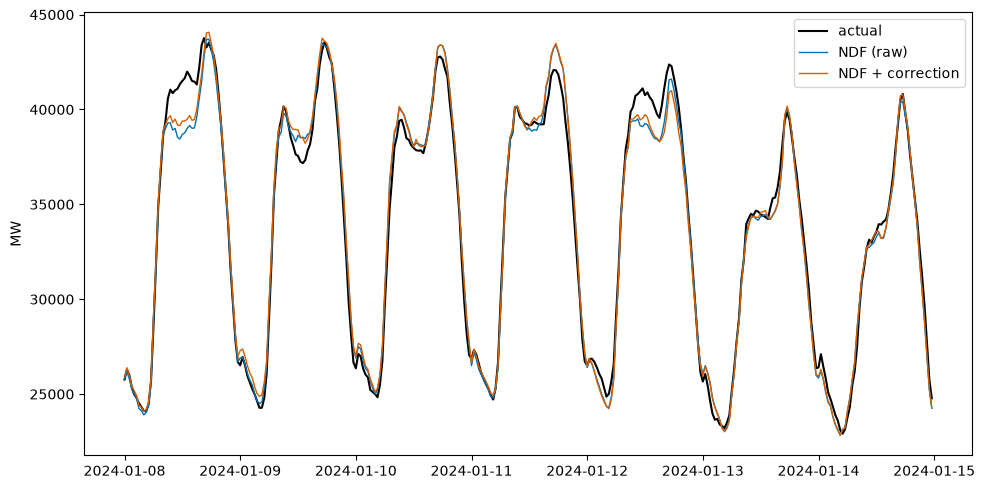

In [6]:
window = slice("2024-01-08", "2024-01-14")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(demand.loc[window].index, demand.loc[window], color="black", label="actual", linewidth=1.5)
ax.plot(ndf_val.loc[window].index, ndf_val.loc[window], color="#0072B2", label="NDF (raw)", linewidth=1)
ax.plot(preds_corrected.loc[window].index, preds_corrected.loc[window], color="#D55E00", label="NDF + correction", linewidth=1)
ax.set_ylabel("MW")
ax.legend()
fig.tight_layout()

## Synthesis: this is a real, deployable improvement — just not from the mechanism hypothesized

The plot above shows why the correction barely helps: NDF (blue) is already tracking actual demand (black) closely, trough included, so there's little residual left for a correction model to meaningfully fix — the orange line sits almost on top of the blue one all week.

**Answering the original question** (is there free, legitimate, deployable data that improves on our model): **yes, clearly** — but the win is *using NDF itself*, not the ML correction layered on it. That's a different, more useful conclusion than either prior attempt: `notebooks/17`'s leaky fuel-mix data barely dented the gap even in its best-case, non-deployable form; this notebook's non-leaky NDF closes nearly all of it, deployably, without needing any correction model at all.

**Practical implication for how this project's model should be framed going forward**: not "beat NESO from scratch" (notebook 16's original framing, now understood to understate NESO's real advantage once compared at full half-hourly resolution), and not "a correction layer adds real value" (this notebook's original hypothesis, not borne out) — but "NDF is a strong forecast on its own, and the honest, useful thing our model can still offer is the ~1.5-year TRAIN window before NDF's archive starts, or a fallback for whenever NDF is unavailable, plus whatever small trough-specific bias reduction the correction genuinely does provide." A modest, defensible conclusion — not the dramatic one hoped for, but a real one, backed by a fair matched-TRAIN comparison rather than an inflated one.